## <font>Data Management for Data Science Final Project</font>
## <font color="brown"> Project Name: Manipulative Text Detector Project </font>
By: Kavya Barathy

## 1. Import Libraries
Explanation: In this section, I install or import the required libraries for this project

In [116]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 7.4 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [117]:
import json
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

## 2. Uploading Dataset + Data Cleaning
Explanation: In this section, I will upload the dataset from Kaggle and clean it up so that only the necessary features are left. I will also clean up the data in the columns to make it easier to use for the model.

In [85]:
#Uploading Dataset
path = 'manipulational_conversation[1].jsonl'
df_raw = pd.read_json(path, lines=True)

#Prints the different columns in the dataset
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(5)

Columns: ['conversation_id', 'manipulation_type', 'is_manipulation', 'context_type', 'conversation_length', 'manipulation_intensity', 'messages', 'target_confusion', 'guilt_level', 'fear_level', 'anxiety_level', 'self_doubt', 'target_extraversion', 'target_emotional_resilience', 'target_assertiveness', 'target_attachment_style', 'avg_response_delay_seconds', 'escalation_pattern', 'word_count_total', 'question_count', 'denial_count']


,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,target_confusion,guilt_level,fear_level,...,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,target_attachment_style,avg_response_delay_seconds,escalation_pattern,word_count_total,question_count,denial_count
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{'speaker': 'A', 'text': 'Remember when I hel...",0.136,0.797,0.224,...,0.306,0.375,0.101,0.222,disorganized,162,sudden,28,1,0
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{'speaker': 'A', 'text': 'I don't tell just a...",0.219,0.306,0.041,...,0.459,0.366,0.380,0.342,secure,93,gradual,51,2,5
2,conv_00002,direct_coercion,True,family,7,0.651,"[{'speaker': 'A', 'text': 'Just do it', 'senti...",0.253,0.166,0.760,...,0.335,0.259,0.064,0.201,anxious,58,gradual,37,1,6
3,conv_00003,gaslighting,True,friend,6,0.673,"[{'speaker': 'A', 'text': 'You're being way to...",0.702,0.123,0.194,...,0.799,0.987,0.168,0.422,disorganized,342,cyclical,41,0,5
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{'speaker': 'A', 'text': 'Go ahead. Have fun....",0.173,0.666,0.126,...,0.355,0.120,0.331,0.787,secure,299,cyclical,25,1,2


In [86]:
#Feature Engineering + Cleaning
df = df_raw[['manipulation_type', 'is_manipulation', 'messages']].copy()

#Combines the messages into one string and makes it all lowercase
df['combined_msgs'] = df['messages'].apply(lambda msg_list: ' '.join(msg.get('text', '') for msg in msg_list))
df['combined_msgs'] = df['combined_msgs'].apply(lambda msg: str(msg).lower())

#Gets rid of the sentiment score because we want to train the model only on the messages
df['combined_msgs'] = df['combined_msgs'].str.replace(r'(sentiment_score).*', r'\1', regex=True)

#Fills empty rows with spaces
df['combined_msgs'] = df['combined_msgs'].fillna('')
df.head()

,manipulation_type,is_manipulation,messages,combined_msgs
0,guilt_tripping,True,"[{'speaker': 'A', 'text': 'Remember when I hel...","remember when i helped you? so, i'm just reall..."
1,charm_flattery,True,"[{'speaker': 'A', 'text': 'I don't tell just a...","i don't tell just anyone this, but i really va..."
2,direct_coercion,True,"[{'speaker': 'A', 'text': 'Just do it', 'senti...","just do it um, i contribute too. barely. witho..."
3,gaslighting,True,"[{'speaker': 'A', 'text': 'You're being way to...",you're being way too sensitive about this. i j...
4,guilt_tripping,True,"[{'speaker': 'A', 'text': 'Go ahead. Have fun....",go ahead. have fun. i'll just stay here alone....


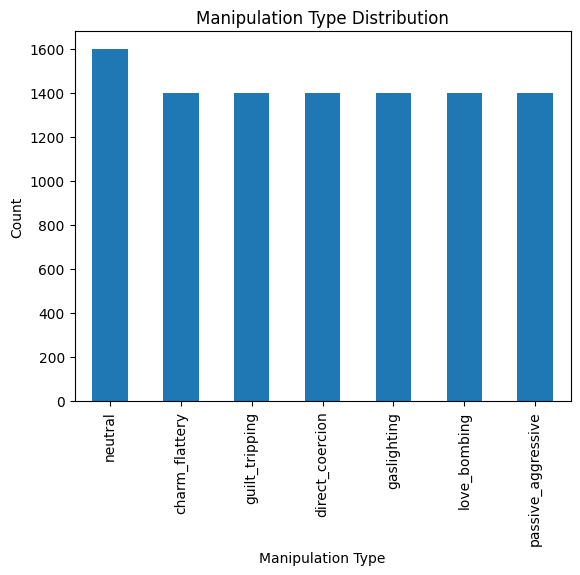

In [107]:
#Visual representation of the distribution of the manipulation types in the dataset
fig = plt.subplot()

#Counts the frequency of each manipulation type in the dataset
df['manipulation_type'].value_counts().plot(kind='bar', ax=fig)
fig.set_title('Manipulation Type Distribution')
fig.set_xlabel('Manipulation Type')
fig.set_ylabel('Count')
plt.show()

## 3. Encoding
Explanation: Uses label encoder to represent each manipulation type as a number 

In [87]:
le = LabelEncoder()

#Creates a new column with the numerical labels of each manipulation type
df['label'] = le.fit_transform(df['manipulation_type'])
df[['label', 'manipulation_type']].head(10)

,label,manipulation_type
0,3,guilt_tripping
1,0,charm_flattery
2,1,direct_coercion
3,2,gaslighting
4,3,guilt_tripping
5,4,love_bombing
6,1,direct_coercion
7,4,love_bombing
8,4,love_bombing
9,5,neutral


## 4. Training
Explanation: In this section, I split the data into training and testing data for the Random Forest and a Logistic Regression model to see what model is better for this dataset based on its accuracy

In [108]:
#Train/Test Split
X = df['combined_msgs'] 
y = df['label']

#Split the data into 30% testing data and 70% training data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=45)

#The Tfidf Vectorizer function turns the words into numbers by scoring the importance of words for the model
#The max_features being set to 5000 means that only 5000 of the most important words will be considered
vectorizer = TfidfVectorizer(max_features=5000)
x_train_vec = vectorizer.fit_transform(x_train)   
x_test_vec = vectorizer.transform(x_test)

#Checks if the test/train split was successfully done
print(f'Training samples: {x_train_vec.shape[0]}')
print(f'Test samples: {x_test_vec.shape[0]}')

#Creates the Random Forest model with 100 trees and trains it on the training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=45)
rf_model.fit(x_train_vec, y_train)

#Creates the Logistic Regression model with 1000 iterations and trains it on the training data
lr_model = LogisticRegression(max_iter=1000, random_state=45)
lr_model.fit(x_train_vec, y_train)

Training samples: 7000
Test samples: 3000


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",45
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 5. Testing
Explanation: In this section, I compare the Random Forest model (rf_model) to the Logistic Regression model (lr_model) to see which one is more accurate for the purposes of this project

In [102]:
#Finds the rf_model's predictions when fed the x test data and computes its accuracy score
y_rf_pred = rf_model.predict(x_test_vec)
print(f"RF Model Accuracy: {accuracy_score(y_test, y_rf_pred):.2%}")

#Finds the lr_model's predictions when fed the x test data and computes its accuracy score
y_lr_pred = lr_model.predict(x_test_vec)
print(f"LR Model Accuracy: {accuracy_score(y_test, y_lr_pred):.2%}")

RF Model Accuracy: 99.87%
LR Model Accuracy: 99.97%


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       428
           1       1.00      1.00      1.00       426
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       446
           4       1.00      1.00      1.00       420
           5       1.00      1.00      1.00       484
           6       1.00      1.00      1.00       411

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



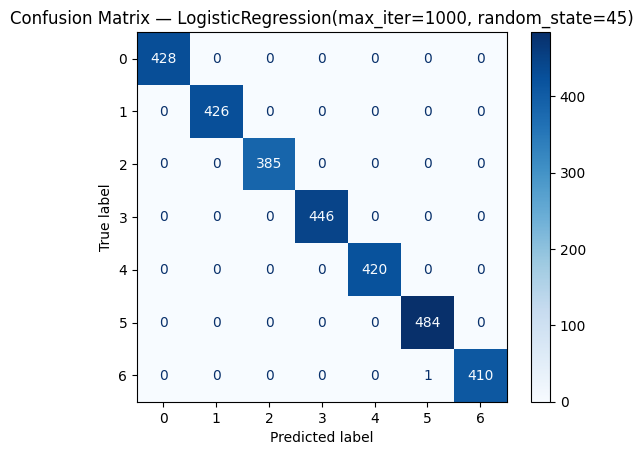

In [112]:
#Creates a report of the better model which is the lr_model
print(classification_report(y_test, y_lr_pred))

#Confusion Matrix of the lr_model to show how it performed
fig = plt.subplot()
ConfusionMatrixDisplay.from_predictions(y_test, y_lr_pred, display_labels=lr_model.classes_, ax=fig, cmap='Blues')
fig.set_title(f'Confusion Matrix — {lr_model}')
plt.show()

In [ ]:
#Getting the important words and the weights assigned to it by lr_model
weights = lr_model.coef_[0]
words = vectorizer.get_feature_names_out()

#Creates a dictionary of the words with their importance
word_dict = {words[i]: abs(weights[i]) for i in range(len(words))}

#Generates the Word Cloud
wc = WordCloud().generate_from_frequencies(word_dict)
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Predictive Words for Manipulation Detection")
plt.show()

## 6. Working Model
Explanation: In this section, I save the model to be used on user-inputted text so that a working model can be created from this code.

In [98]:
#Allows the model to be saved and used
joblib.dump(lr_model, 'manipulation_model.pkl')
joblib.dump(le,'label_encoder.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [99]:
#Loads the previously trained models
model = joblib.load('manipulation_model.pkl')
le = joblib.load('label_encoder.pkl')
vectorizer = joblib.load('vectorizer.pkl')

#Function that uses the model to make predictions on user-inputted text
def predict_manipulation(text):
    #Cleans the user-inputted text
    clean_text = str(text).lower()

    #Turns the text into numbers using vectorizer
    vec_text = vectorizer.transform([clean_text])

    #Gets the probabilities of each manipulation_type and retrieves the manipulation type with the highest probability
    proba = model.predict_proba(vec_text)[0]
    pred_index = int(np.argmax(proba))

    #Transforms the label back to a word instead of the number
    pred_label = le.inverse_transform([pred_index])[0]

    #Gets the confidence percentage of the prediction
    confidence = round(float(proba[pred_index]) * 100, 1)

    #Returns a dictionary with the manipulation type and the confidence percentage
    return {
        'manipulation_type': pred_label,
        'confidence': confidence,
    }

In [100]:
print("Test it out!")
print('Type "done" to exit the testing module')

#Gets text from the user to run through the model
user_input = input("Insert the text you want to check for manipulation: ")

#Runs the user-inputted text through the method described above
result = predict_manipulation(user_input)   
print("")

#Prints the model's prediction which includes the manipulation type and how confident it is
print("Result:")
print(f'Text: "{user_input}"')
print(f"Manipulation Type: {result["manipulation_type"]}")
print(f"Confidence: {result["confidence"]}%")
while user_input != "done":
    user_input = input("Insert the text you want to check for manipulation: ")
    result = predict_manipulation(user_input)   
    print("")
    print("Result:")
    print(f'Text: "{user_input}"')
    print(f"Manipulation Type: {result["manipulation_type"]}")
    print(f"Confidence: {result["confidence"]}%")

Test it out!
Type "done" to exit the testing module


Insert the text you want to check for manipulation:  I hate you!



Result:
Text: "I hate you!"
Manipulation Type: love_bombing
Confidence: 31.9%


Insert the text you want to check for manipulation:  hello



Result:
Text: "hello"
Manipulation Type: neutral
Confidence: 33.0%


Insert the text you want to check for manipulation:  you have to do this with me or else



Result:
Text: "you have to do this with me or else"
Manipulation Type: direct_coercion
Confidence: 60.0%


Insert the text you want to check for manipulation:  I will be very mad



Result:
Text: "I will be very mad"
Manipulation Type: passive_aggressive
Confidence: 36.0%


Insert the text you want to check for manipulation:  I don't care, do whatever you want



Result:
Text: "I don't care, do whatever you want"
Manipulation Type: passive_aggressive
Confidence: 22.4%


Insert the text you want to check for manipulation:  Good for you



Result:
Text: "Good for you"
Manipulation Type: neutral
Confidence: 56.8%


Insert the text you want to check for manipulation:  done



Result:
Text: "done"
Manipulation Type: guilt_tripping
Confidence: 33.2%
